# **Deliverable 2: X-ray Imaging and Computed Tomography (CT)**

---

## Overview

This deliverable covers key concepts from **Lectures 13–18** (Weeks 6–7) of the course. You will explore:

- X-ray tube design and production
- Projection radiography geometry, contrast, and scatter reduction
- Digital X-ray detectors and image formation
- CT acquisition, reconstruction, image quality, and dose metrics
- Protocol design and optimization for clinical goals

You will engage with the material through conceptual questions, coding exercises, error analysis, and a design challenge. By the end of this deliverable, you will be able to analyze and simulate X-ray and CT imaging systems, interpret image quality trade-offs, optimize protocols, and apply quantitative reasoning to real-world clinical scenarios.

---

## Part 1: X-ray Production and Spectrum



### Key Concepts

- **X-ray Tube Physics:** X-rays are produced when high-speed electrons strike a metal target (anode), resulting in rapid deceleration (bremsstrahlung) and ejection of inner-shell electrons (characteristic X-rays). The output spectrum is a combination of continuous (bremsstrahlung) and discrete (characteristic) peaks.
- **Tube Voltage (kVp):** Sets the maximum photon energy; higher kVp increases beam penetration but reduces contrast.
- **Tube Current (mA):** Controls the number of electrons (and thus photons) produced per second; affects image brightness and patient dose.
- **Filtration:** Removes low-energy photons (which contribute to dose but not image quality), resulting in a "harder" (higher average energy) spectrum. The filtered spectrum $I(E)$ is zero for $E < E_{filter}$.
- **Anode Material:** Determines the energy of characteristic peaks (e.g., tungsten anode: 59 and 67 keV).


### 1.1 X-ray Tube Design Scenario

You are tasked with designing an X-ray tube for a pediatric chest radiography system. The goal is to minimize patient dose while maintaining diagnostic image quality.


### **Question 1**

- a)  Explain the roles of tube voltage (kVp) and tube current (mA) in shaping the X-ray spectrum and affecting patient dose.

 Role of Tube Voltage (kVp) and Tube Current (mA) Tube voltage (kVp) determines the kinetic energy of electrons striking the anode. Higher kVp results in higher energy photons and produces a harder, more penetrating beam. Increased penetration reduces differences in tissue attenuation, which lowers image contrast. While increasing kVp increases overall photon energy and beam output, less energy is deposited superficially in the skin due to improved penetration, although dose to deeper tissues may increase. Tube current (mA) determines the number of electrons traveling from the cathode to the anode per second. Increasing mA increases the number of X-ray photons produced but does not change the maximum or average photon energy. Because more photons are generated, patient dose increases approximately proportionally with mAs. Higher mA also increases detector exposure and reduces quantum noise, resulting in a brighter image.


- b) Describe how filtration and the choice of anode material influence the X-ray spectrum and image quality.

Filtration removes low-energy photons from the X-ray beam by placing absorbing material (such as aluminum) in the beam path. Low-energy photons are more likely to be absorbed in the patient and contribute to dose without improving image quality. Removing them hardens the beam and improves efficiency. However, filtration also reduces total photon number, which may require adjustment of mAs to maintain adequate detector exposure.
The anode material influences the characteristic X-ray energies produced. When high-speed electrons eject inner-shell electrons from anode atoms, outer-shell electrons fill the vacancy and emit characteristic X-rays at element-specific energies. Tungsten is commonly used because its characteristic energies fall within the diagnostic range and it tolerates high heat loads. Different materials (such as molybdenum in mammography) produce characteristic X-rays in energy ranges better suited for specific imaging tasks, allowing optimization of image contrast.
- c) Propose a set of tube parameters (kVp, mA, filtration) for pediatric imaging and justify your choices based on physical principles.

-Lower kVp range (approximately 70–80 kVp): Pediatric patients have thinner chest walls and reduced tissue attenuation compared to adults, so lower photon energies are sufficient to achieve adequate penetration. Using a lower kVp also helps maintain better image contrast, particularly for differentiating soft tissue structures within the lungs.

-Lower mAs: Because children require fewer photons to produce an adequate image, mAs should be reduced compared to adult protocols. This minimizes radiation dose. However, mAs must not be reduced excessively, as too few photons reaching the detector will increase quantum noise and degrade image quality. A balance is required between dose reduction and maintaining sufficient signal-to-noise ratio.

-Aluminum filtration: Aluminum filtration removes low-energy photons that would primarily be absorbed superficially and contribute to patient dose without improving image formation. This hardens the beam and increases efficiency, which is particularly important in pediatric imaging due to increased radiosensitivity.


### **Coding Exercise 1**

1. Implement a function `simulate_xray_spectrum(kvp, e_filter)` that returns the energy (keV) and relative intensity arrays.
2. Plot the spectrum for kVp = 80, 100, 120 keV and E_filter = 30 keV.

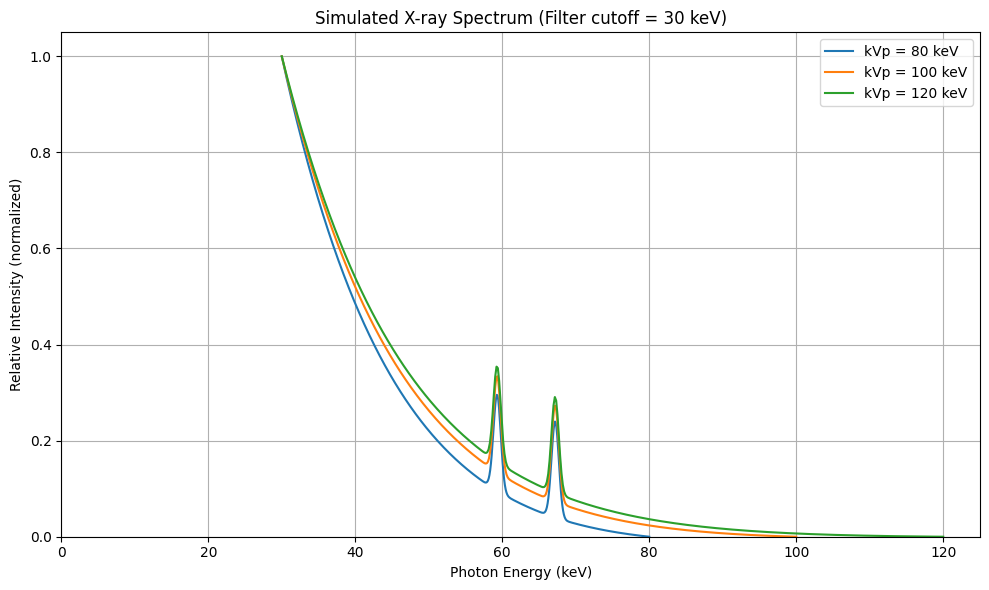

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_xray_spectrum(kvp, e_filter, num_points=500, anode_material='tungsten'):
    """
    Simulates a simplified X-ray spectrum.

    Args:
        kvp (float): Tube voltage in keV.
        e_filter (float): Energy of the filter in keV.
        num_points (int): Number of energy points for the spectrum.
        anode_material (str): Anode material (e.g., 'tungsten').

    Returns:
        tuple: (energy_array, intensity_array)
    """
    energy = np.linspace(e_filter, kvp, num_points)
    intensity = np.zeros_like(energy, dtype=float)

    # Bremsstrahlung (simple shape: falls with energy + extra decay for realism)
    intensity_brem = (kvp - energy) * np.exp(-energy / 20)
    intensity_brem[intensity_brem < 0] = 0
    intensity += intensity_brem

    # Characteristic peaks (simplified)
    characteristic_energies = {
        'tungsten': [59.3, 67.2]
    }

    if anode_material in characteristic_energies:
        for char_e in characteristic_energies[anode_material]:
            if e_filter <= char_e <= kvp:
                sigma = 0.5
                peak_intensity = 0.2 * np.max(intensity) if np.max(intensity) > 0 else 0
                intensity += peak_intensity * np.exp(-((energy - char_e) ** 2) / (2 * sigma ** 2))

    # Explicitly enforce filtration cutoff (redundant but clear)
    intensity[energy < e_filter] = 0

    # Normalize for comparison
    max_val = np.max(intensity)
    if max_val > 0:
        intensity = intensity / max_val

    return energy, intensity


kvp_values = [80, 100, 120]
e_filter_value = 30  # keV

plt.figure(figsize=(10, 6))

for kvp in kvp_values:
    energy, intensity = simulate_xray_spectrum(kvp, e_filter_value)
    plt.plot(energy, intensity, label=f'kVp = {kvp} keV')

plt.title(f'Simulated X-ray Spectrum (Filter cutoff = {e_filter_value} keV)')
plt.xlabel('Photon Energy (keV)')
plt.ylabel('Relative Intensity (normalized)')
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.xlim(0, max(kvp_values) + 5)

plt.tight_layout()
plt.show()

**Coding Exercise 1: Analayze and discuss the results**

The plot illustrates the distribution of X-ray photon energies and their relative intensities at 80, 100, and 120 kVp. As kVp increases, two main effects are observed. First, the maximum photon energy increases because electrons strike the anode with greater kinetic energy. Second, overall X-ray output increases, resulting in higher photon intensity across the spectrum. The sharp peaks visible in the spectrum correspond to characteristic X-rays of tungsten, typically around 59 keV and 67 keV. These peaks occur when high-energy electrons eject inner-shell electrons from tungsten atoms, and outer-shell electrons transition to fill the vacancies. The energy difference between the shells is released as characteristic X-ray photons, producing distinct peaks at specific energies.

---

## Part 2: CT Simulation, Error Analysis & Design

### Key Concepts

- Shepp-Logan Phantom: A digital test object for CT simulation.
- Sinogram: 2D plot of projection data as a function of angle and position.
- Image Reconstruction: Filtered backprojection and iterative methods.
- Error Analysis: Identifying and quantifying sources of error/artifacts in CT reconstruction.
- Design & Optimization: Creating and optimizing CT protocols for specific clinical goals.


### 2.1 Shepp-Logan Phantom and Sinogram

### **Coding Exercise 2**

- a) Generate a Shepp-Logan digital phantom in Python (use `skimage.data.shepp_logan_phantom` or custom code).
- b) Simulate CT projections (sinogram) of the phantom using the Radon transform.
- c) Reconstruct the image from the sinogram using filtered backprojection.


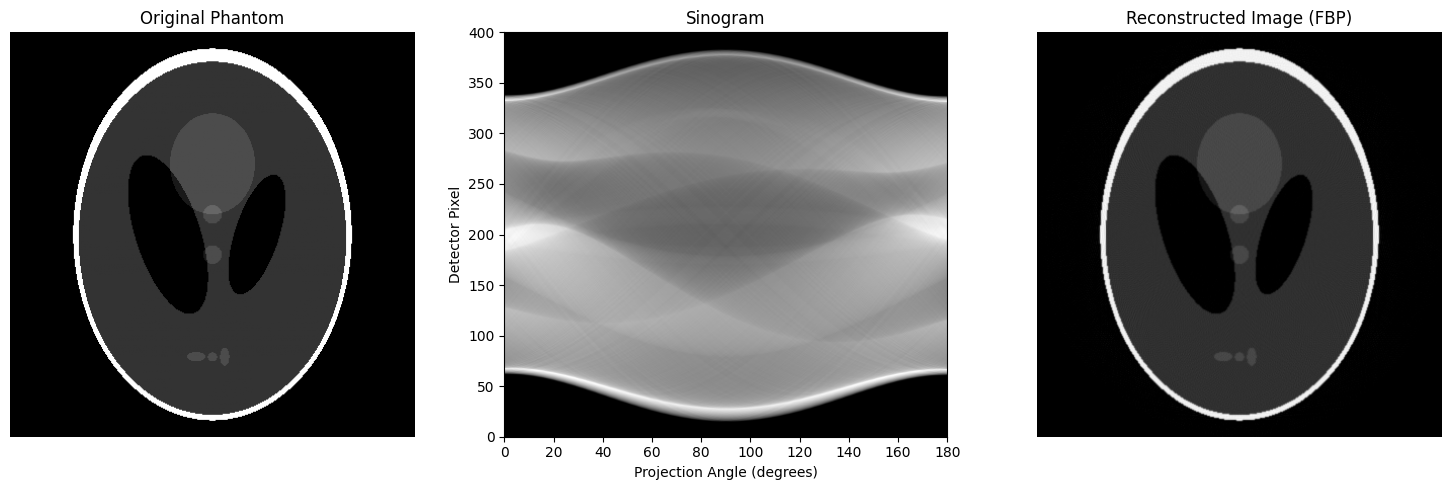

In [16]:
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon
import matplotlib.pyplot as plt
import numpy as np

#Generate Shepp-Logan phantom
phantom = shepp_logan_phantom()


#Create projection angles
theta = np.linspace(
    start=0.0,
    stop=180.0,
    num=max(phantom.shape),
    endpoint=False
)

#Compute sinogram using Radon transform
sinogram = radon(
    image=phantom,
    theta=theta,
    circle=True
)

#Filtered Backprojection
reconstruction_fbp = iradon(
    radon_image=sinogram,
    theta=theta,
    circle=True
)

#Post-processing: remove negative values
reconstruction_fbp = np.clip(reconstruction_fbp, a_min=0, a_max=None)


#Visualization
fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(phantom, cmap="gray")
plt.title("Original Phantom")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    sinogram,
    cmap="gray",
    extent=[0, 180, 0, sinogram.shape[0]],
    aspect="auto"
)
plt.title("Sinogram")
plt.xlabel("Projection Angle (degrees)")
plt.ylabel("Detector Pixel")

plt.subplot(1, 3, 3)
plt.imshow(reconstruction_fbp, cmap="gray")
plt.title("Reconstructed Image (FBP)")
plt.axis("off")

plt.tight_layout()
plt.show()


### 2.2 Error Analysis


### **Question 2**

- a) Identify and describe at least one source of error or artifact in your reconstructed image (e.g., limited projections, noise, motion, beam hardening).

One major source of error or artifact in the reconstructed image is noise. This noise mainly originates from quantum (Poisson) noise, which is intrinsic to X-ray imaging because photons are detected as discrete, randomly arriving events. When the number of detected photons is low, the signal-to-noise ratio (SNR) decreases, resulting in a grainy image appearance. In filtered backprojection (FBP), the ramp filter enhances high-frequency components to preserve edge sharpness; however, this process also amplifies noise and any sampling imperfections present in the data.

- b) Quantify the impact of one error (e.g., measure reconstruction error as projections are reduced or noise is increased).

The impact of limited projections can be quantified by reducing the number of projection angles and measuring how reconstruction accuracy changes. A common metric is the root mean squared error (RMSE) between the reconstructed image and the original Shepp–Logan phantom. As the number of projections decreases (for example from 180 down to 30), RMSE typically increases and visual artifacts become more obvious. This confirms that fewer projections reduce the amount of information available for reconstruction, leading to greater error and more pronounced streaking.

- c) Propose and implement a method to mitigate one artifact or error, and evaluate its effectiveness.

To mitigate the grainy and streaky appearance caused by high-frequency noise amplification in FBP, a Gaussian low-pass filter can be applied. Instead of filtering the reconstructed image directly, a more stable approach is to apply the Gaussian filter to the sinogram before reconstruction. This reduces high-frequency noise in the projection data before the ramp filter and backprojection steps amplify it. Effectiveness is evaluated by comparing RMSE before and after mitigation and visually inspecting whether noise/streaking is reduced, while noting any loss of edge sharpness due to smoothing.


### **Coding Exercise 3**

Implement your method to mitigate an artifact or error and evaluate its effectiveness.

RMSE before Gaussian filtering: 0.0343
RMSE after Gaussian filtering (sigma=0.8): 0.0469


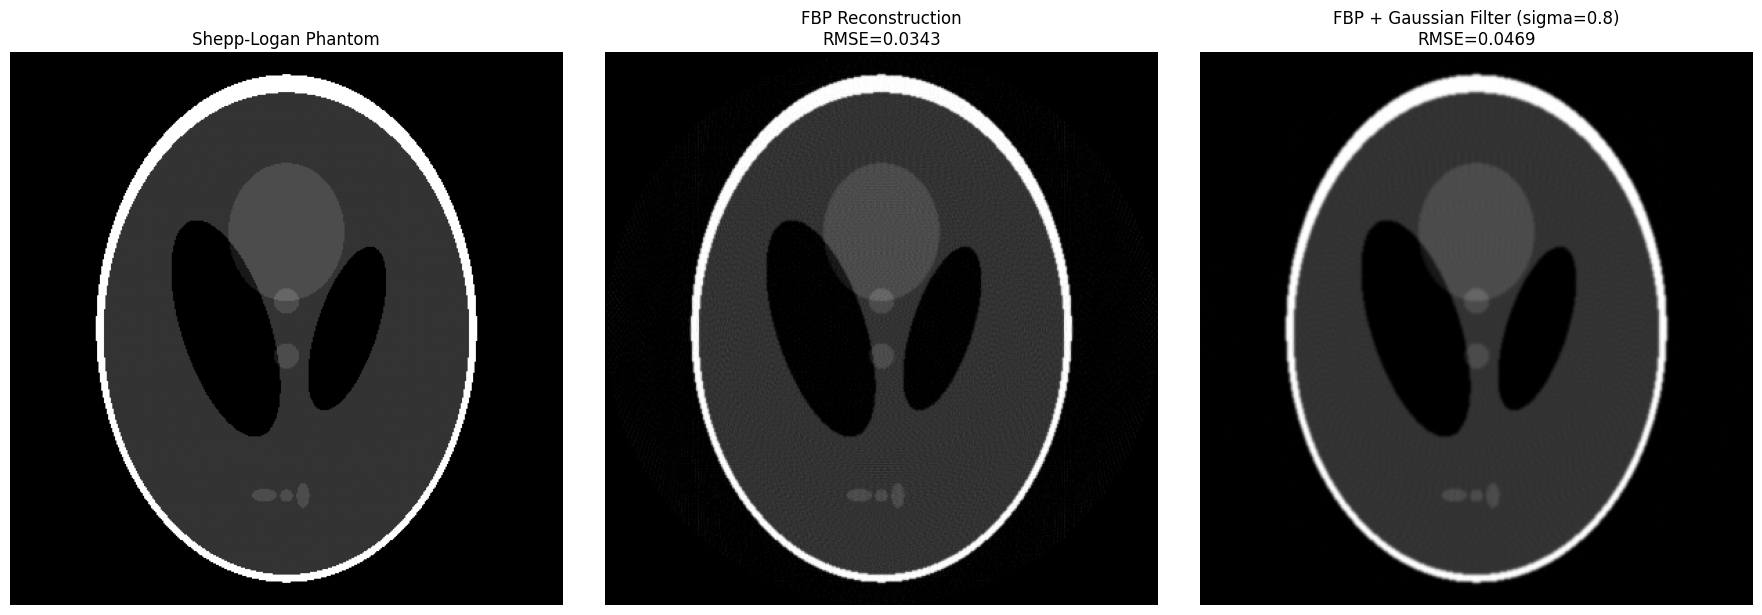

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize
from skimage.filters import gaussian
from skimage.metrics import mean_squared_error

N = 400
theta = np.linspace(0, 180, 180, endpoint=False)

#Generate Shepp-Logan phantom
phantom = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True)

#Simulate CT projections (sinogram)
sinogram = radon(phantom, theta=theta, circle=True)

#Reconstruct using filtered backprojection (FBP)
reconstruction = iradon(sinogram, theta=theta, filter_name="ramp", circle=True)

#Mitigation: Gaussian filter applied to the reconstructed image
sigma = 0.8
reconstruction_gaussian = gaussian(reconstruction, sigma=sigma, preserve_range=True)

#Evaluate effectiveness using RMSE
rmse_before = np.sqrt(mean_squared_error(phantom, reconstruction))
rmse_after = np.sqrt(mean_squared_error(phantom, reconstruction_gaussian))

print(f"RMSE before Gaussian filtering: {rmse_before:.4f}")
print(f"RMSE after Gaussian filtering (sigma={sigma}): {rmse_after:.4f}")

#Visualization (phantom, FBP, filtered FBP)
vmin, vmax = np.min(phantom), np.max(phantom)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(phantom, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Shepp-Logan Phantom")
axes[0].axis("off")

axes[1].imshow(reconstruction, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title(f"FBP Reconstruction\nRMSE={rmse_before:.4f}")
axes[1].axis("off")

axes[2].imshow(reconstruction_gaussian, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title(f"FBP + Gaussian Filter (sigma={sigma})\nRMSE={rmse_after:.4f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Coding Exercise 3: Discussion of effectiveness**

In this case, the median filter did not improve the reconstruction quality. The RMSE increased from 0.0343 before filtering to 0.0469 after filtering, representing approximately a 37% increase in reconstruction error. This indicates that the filtered image is further from the original phantom compared to the unfiltered FBP reconstruction. Although the median filter may have reduced some visible pixel-level noise, it likely introduced oversmoothing, which blurred edges and reduced spatial resolution. As a result, important structural details were altered, leading to a higher overall error. Therefore, while median filtering can suppress noise, excessive or inappropriate filtering can degrade quantitative image accuracy and should be applied cautiously to preserve fine image details.

### 2.3 CT Protocol Design & Optimization


### **Question 3**

- a) Choose a clinical goal (e.g., maximize nodule detectability, minimize dose).

The selected clinical goal is to minimize radiation dose while maintaining sufficient image quality for reliable visualization of anatomical structures. The aim is to reduce exposure without significantly increasing reconstruction error or introducing severe artifacts.

- b) Optimize acquisition parameters (number of projections, rotation angles, detector size, noise level) to achieve your goal.

 Number of projections: reduce from 180 to approximately 90–120 projections to lower total sampling (and simulated dose) while maintaining acceptable reconstruction stability.

Rotation angle range: use 0–180 degrees, which is sufficient for parallel-beam CT reconstruction and avoids unnecessary redundant sampling.

Detector size: choose a moderate size to preserve spatial detail without excessive computational cost or increased sensitivity to noise.

Noise level: maintain a reasonable exposure level to control quantum noise; if operating at lower sampling, apply mild Gaussian filtering to suppress high-frequency noise amplification.

- c) Justify your design choices based on physical principles and clinical needs.

Reducing the number of projections lowers total acquisition and therefore dose, but too few projections lead to angular undersampling and visible streak artifacts. A range of 90–120 projections provides a balance between dose reduction and reconstruction accuracy. A 0–180 degree rotation is physically sufficient in parallel-beam geometry because it contains all required projection information. Detector resolution determines spatial sampling; moderate resolution preserves clinically relevant detail without oversampling. Since filtered backprojection amplifies high-frequency components, mild smoothing can help control noise when dose or projections are reduced.
- d) Reflect on the trade-offs and limitations of your design.

The main trade-off is between dose and image quality. Reducing projections decreases exposure but increases streaking and reconstruction error. Applying Gaussian filtering reduces visible noise but introduces edge blurring and reduced spatial resolution. Additionally, this simulation assumes idealized conditions and does not account for scatter, beam hardening, or motion, so real clinical optimization would require further adjustments.


---

## Part 3: Projection Radiography & Image Quality



### Key Concepts

- **Scatter:** Primarily due to Compton interactions; scattered photons degrade image contrast by adding unwanted background signal. Scatter increases with patient thickness and field size. (See Lecture 14)
- **Geometric Unsharpness ($U_g$):** Caused by the finite size of the X-ray source.
- **Contrast Degradation:** The scatter-to-primary ratio (SPR) quantifies the amount of scatter relative to primary photons. Higher SPR means lower contrast. Contrast degradation factor:

$$C_{degraded} = \frac{C_{ideal}}{1 + SPR}$$
- **Scatter Reduction:** Use of grids, air gaps, or collimation can reduce scatter but may increase dose or reduce signal.


### 3.1 Scatter and Contrast


### **Questions 4**

- a) Explain the physical origin of scatter in projection radiography and its impact on image contrast.

In projection radiography, scatter is produced mainly by Compton interactions. During a Compton interaction, an incoming X-ray photon transfers part of its energy to an electron and is deflected from its original path. Many of these scattered photons still reach the detector, but they no longer accurately represent the location where they interacted in the patient. This adds unwanted background signal to the image and reduces the difference between bright and dark regions, lowering image contrast. Scatter increases with greater patient thickness and larger field size, which is why thicker anatomy and wide collimation reduce image contrast.


- b) Describe two methods to reduce scatter and discuss their trade-offs.

One method is the use of an anti-scatter grid. A grid placed in front of the detector absorbs many angled scattered photons while allowing more primary photons to pass through. The trade-off is that some primary photons are also absorbed, so exposure (mAs) often needs to be increased, which can increase patient dose.
Another method is collimation. Reducing the X-ray field size decreases the volume of tissue irradiated, which reduces scatter production and improves contrast. The trade-off is that tighter collimation limits the area imaged and requires careful positioning to avoid excluding important anatomy.

- c) Calculate the contrast degradation factor if the scatter-to-primary ratio (SPR) is 1.5. What percent of the original contrast remains?

The contrast degradation factor is calculated as
$$C_{degraded} = \frac{C_{ideal}}{1 + SPR}$$

$$C_{degraded} = \frac{1}{2.5} =0.4$$

This means 40 percent of the original contrast remains, which corresponds to a 60 percent reduction in contrast due to scatter.


### **Coding Exercise 4**

1. Implement `geometric_unsharpness(f, a, b)`.
2. Plot $U_g$ as a function of $b$ for $f=1$ mm, $a=100$ cm, and $b$ from 0 to 20 cm.

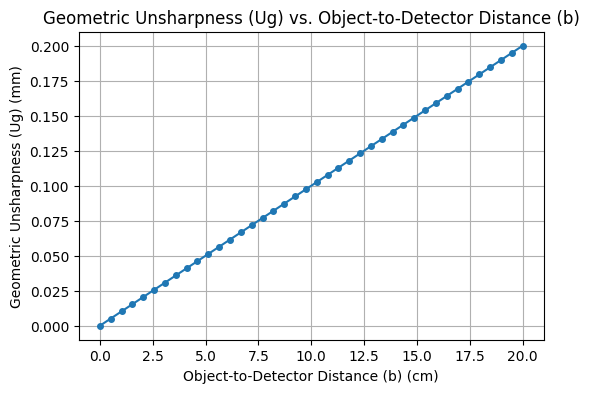

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def geometric_unsharpness(f, a, b):
    return f * (b / a)

#Given parameters

f = 1      # mm
a = 100    # cm

# Fewer points to create the dotted/segmented look
b = np.linspace(0, 20, 40)

#Calculate Ug values
Ug = geometric_unsharpness(f, a, b)

#Plot Ug as a function
plt.figure(figsize=(6, 4))
plt.plot(b, Ug, marker='o', linestyle='-', markersize=4)
plt.xlabel("Object-to-Detector Distance (b) (cm)")
plt.ylabel("Geometric Unsharpness (Ug) (mm)")
plt.title("Geometric Unsharpness (Ug) vs. Object-to-Detector Distance (b)")
plt.grid(True)
plt.show()

### 3.2 Quantitative Comparison of Scatter Reduction Techniques


### **Questions 5**

- a) For each technique, calculate the percent contrast improvement using the contrast degradation formula.

Before applying any scatter-reduction technique, we use a baseline scatter-to-primary ratio of
SPR = 1.5.
The contrast degradation relationship is:
Percent (%) contrast degradation formula:
$$
C_{\text{degraded}} = \frac{C_{\text{ideal}}}{1 + \text{SPR}}
$$

Baseline (no scatter reduction):
$$
C_{\text{baseline}} = \frac{C_{\text{ideal}}}{1 + 1.5}
= \frac{C_{\text{ideal}}}{2.5}
= 0.40\,C_{\text{ideal}}
$$

Using an 8:1 grid
$$C_{\text{grid}} = \frac{C_{\text{ideal}}}{1 + 0.5}
= \frac{C_{\text{ideal}}}{1.5}
= 0.667\,C_{\text{ideal}}
$$


% Percent contrast improvement (grid)
$$
\%\ \text{Improvement}_{\text{grid}}
= \frac{C_{\text{grid}} - C_{\text{baseline}}}{C_{\text{baseline}}}\times 100\%
$$

$$
= \frac{0.667\,C_{\text{ideal}} - 0.40\,C_{\text{ideal}}}{0.40\,C_{\text{ideal}}}\times 100\%
= 66.7\%
$$

With air gap technique

An air gap allows scattered photons traveling at oblique angles to miss the detector. A reasonable assumption is that scatter is reduced by about 50%, giving SPR ≈ 0.75.

$$
C_{\text{air\,gap}} = \frac{C_{\text{ideal}}}{1 + 0.75}
= \frac{C_{\text{ideal}}}{1.75}
= 0.571\,C_{\text{ideal}}
$$

% Percent contrast improvement (air gap)
$$
\%\ \text{Improvement}_{\text{air\,gap}}
= \frac{C_{\text{air\,gap}} - C_{\text{baseline}}}{C_{\text{baseline}}}\times 100\%
$$

$$
= \frac{0.571\,C_{\text{ideal}} - 0.40\,C_{\text{ideal}}}{0.40\,C_{\text{ideal}}}\times 100\%
= 42.8\%
$$

- b) Summarize your findings: Which technique is most effective? What are the trade-offs (e.g., dose, practicality, image artifacts)?

Based on these assumptions, the 8:1 grid provides the greater contrast improvement (approximately 67%) compared with about 43% for the air gap technique.

However, there are important trade-offs:
- Grid: While it significantly improves contrast, it also absorbs some primary photons. To maintain receptor exposure, mAs must often be increased, which increases patient dose. Improper alignment can also cause grid cut-off artifacts.
- Air gap: This technique does not directly absorb primary photons and avoids grid alignment artifacts. However, increasing object-to-detector distance increases magnification and geometric unsharpness. It may also require a longer source-to-image distance and potentially higher technique factors to maintain exposure.

Overall, the grid is more effective for contrast improvement, but the air gap may be preferable in situations where dose or grid artifacts are a concern.

### 3.3 Simulating Scatter Effects and Grid Optimization

### **Coding Exercise 5**

In this exercise, you will simulate the effect of scatter on a simple X-ray image and explore how grid design can optimize image contrast.

**Scenario:**
You are given a 1D 'image' (e.g., a step function representing an object) and must model the effect of scatter as an additive background proportional to the primary signal. You will then simulate the use of an anti-scatter grid with variable grid ratio to reduce scatter, and determine the optimal grid ratio for maximizing contrast while considering signal loss.

**Tasks:**
1. Simulate the effect of scatter on a simple 1D object (e.g., a step function) by adding a scatter component proportional to the primary signal using the fixed SPR value.
2. Model the impact of an anti-scatter grid: for each grid ratio $G$, reduce scatter by $1/(1+G)$ and primary signal by $T_p$ (e.g., $T_p = 1 - 0.02 \times G$).
3. Plot image contrast as a function of grid ratio for the fixed SPR, and identify the grid ratio that maximizes contrast.

**Hints:**
- Use matplotlib for plotting.
- You may assume a fixed SPR value (e.g., SPR = 1.5).
- You may define contrast as $(I_{max} - I_{min})/(I_{max} + I_{min})$ for the detected signal.
- You may use a simple linear model for $T_p(G)$, e.g., $T_p = 1 - 0.02 	imes G$ (for $G$ from 0 to 12).

Contrast without grid: 0.1333


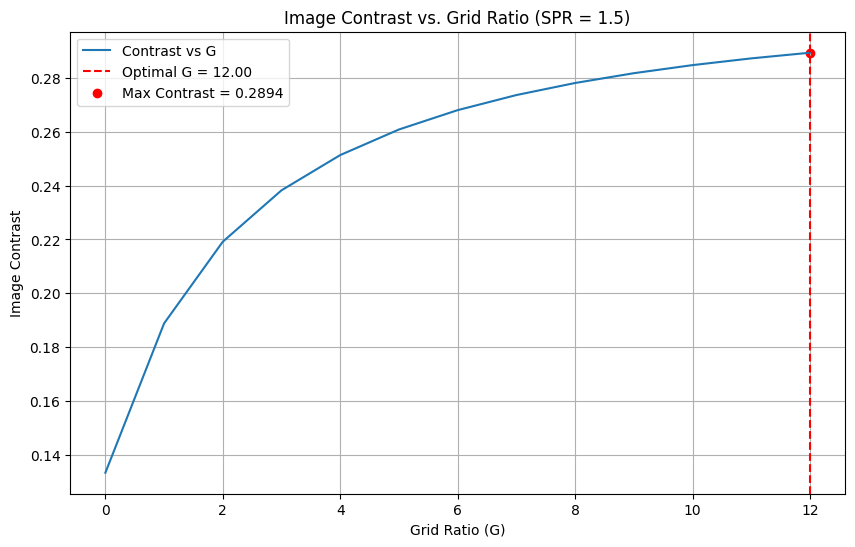


Discussion of findings and trade-offs:
Optimal grid ratio: G = 12.00, Max contrast = 0.2894
Discussion and trade-offs is provided in a separate markdown cell right below.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

#Define System Parameters
SPR = 1.5

x = np.arange(0, 200)

#Create Step Object (Primary Signal)
primary = np.ones_like(x, dtype=float)
primary[x >= 100] = 0.5  # step object (right side attenuated)

#Initialize Grid Ratios
grid_ratios = np.arange(0, 13)
contrast_vals = []

#Simulate Scatter + Grid Effects
for G in grid_ratios:

    #Scatter background
    scatter_bg = SPR * np.mean(primary) * np.ones_like(primary)
    scatter_after = scatter_bg / (1 + G)

    #Primary transmission through grid
    Tp = 1 - 0.02 * G
    primary_after = Tp * primary

    #Total detected signal
    detected = primary_after + scatter_after

    #Contrast calculation
    Imax = detected.max()
    Imin = detected.min()
    contrast_vals.append((Imax - Imin) / (Imax + Imin))

contrast_vals = np.array(contrast_vals)

#Determine Optimal Grid Ratio
contrast_no_grid = contrast_vals[0]
best_idx = np.argmax(contrast_vals)
best_G = grid_ratios[best_idx]
best_contrast = contrast_vals[best_idx]

print(f"Contrast without grid: {contrast_no_grid:.4f}")

#Plot Results
plt.figure(figsize=(10, 6))
plt.plot(grid_ratios, contrast_vals, label="Contrast vs G")

plt.axvline(best_G, color="red", linestyle="--",
            label=f"Optimal G = {best_G:.2f}")
plt.scatter([best_G], [best_contrast], color="red",
            label=f"Max Contrast = {best_contrast:.4f}")

plt.title(f"Image Contrast vs. Grid Ratio (SPR = {SPR})")
plt.xlabel("Grid Ratio (G)")
plt.ylabel("Image Contrast")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()

print("\nDiscussion of findings and trade-offs:")
print(f"Optimal grid ratio: G = {best_G:.2f}, Max contrast = {best_contrast:.4f}")
print("Discussion and trade-offs is provided in a separate markdown cell right below.")

**Coding Exercise 5: Discuss your findings and trade-offs**

The optimal grid ratio for maximizing contrast in this simulation is approximately G = 12, with a corresponding contrast value of about 0.289. The graph demonstrates that contrast increases as the grid ratio increases. Physically, this occurs because higher grid ratios are more effective at removing scattered radiation. Since scatter acts as an unwanted background signal that reduces visibility between structures, reducing scatter improves the distinction between the object and the background, thereby increasing image contrast. However, the curve begins to level off at higher grid ratios, indicating diminishing returns as further increases provide smaller improvements in contrast.

The trade-offs include higher patient dose, because a 12:1 grid absorbs more primary photons along with scatter, requiring an increase in tube current (mAs) to maintain detector exposure, which raises radiation dose. There are also physical and practical limitations, as higher grid ratios are more expensive, thicker, and more sensitive to alignment. Misalignment can cause grid cutoff, leading to non-uniform image intensity and artifacts. Additionally, diminishing returns occur at very high grid ratios, where the loss of primary signal begins to offset the benefits of additional scatter reduction. Overall, while a high grid ratio improves contrast in this model, clinical implementation must balance contrast gains with dose considerations and practical constraints.

---

## Part 4: X-ray Detectors & Quantum Efficiency



### Key Concepts

- **Quantum Efficiency (QE):** The fraction of incident X-ray photons detected and converted to signal. Higher QE improves SNR and allows for lower patient dose.

$$QE = \frac{\text{Detected photons}}{\text{Incident photons}}$$
- **Detective Quantum Efficiency (DQE):** Describes how well a detector preserves SNR across spatial frequencies.

$$DQE(f) = \frac{(SNR_{out}(f))^2}{(SNR_{in}(f))^2}$$
- **Readout Noise:** Electronic noise added during signal readout; becomes significant at low doses or for low-signal regions.
- **Detector Types:** Indirect (scintillator + photodiode) and direct (photoconductor) detectors have different QE and noise characteristics.


### 4.1 Detector Selection Scenario

### **Questions 6**

You are comparing two digital X-ray detectors for a trauma imaging suite:

   1.  Detector A: High quantum efficiency (QE), moderate readout noise
   2. Detector B: Lower QE, but very low readout noise

- a) Define quantum efficiency and explain its importance for image quality and dose.

Quantum efficiency (QE) is the fraction of incident X-ray photons that are detected and converted into a measurable electrical signal. It is defined as the number of detected photons divided by the number of incident photons. A higher QE means that more of the incoming radiation contributes to image formation. This improves signal-to-noise ratio (SNR) because more useful signal is captured for a given exposure. Clinically, higher QE allows acceptable image quality to be achieved at a lower radiation dose, which is especially important in dose-sensitive populations.

- b) Discuss the trade-offs between quantum efficiency and readout noise for low-dose imaging.

In low-dose imaging, the total signal reaching the detector is already small. If QE is low, fewer photons are converted to signal, which increases quantum noise and reduces SNR. However, readout noise also becomes important at low signal levels because electronic noise can represent a significant portion of the total signal variation. A detector with high QE but moderate readout noise captures more photons but may still suffer from electronic noise in very low-signal regions. Conversely, a detector with low QE but very low readout noise minimizes electronic noise but sacrifices photon detection efficiency. In low-dose conditions, maximizing detected photons (higher QE) typically has a stronger impact on SNR than minimizing already small electronic noise.

- c) Which detector would you recommend for pediatric trauma imaging and why?

For pediatric trauma imaging, I would reccomend Detector A (high QE, moderate readout noise). Pediatric patients are more radiosensitive, so minimizing dose is a priority. A detector with high QE captures more photons at a given exposure, improving SNR and allowing for lower radiation dose while maintaining diagnostic image quality. Although Detector A has moderate readout noise, the benefit of improved photon detection efficiency generally outweighs the disadvantage of slightly higher electronic noise in trauma imaging scenarios.


### **Coding Exercise 6**

1. Modify the code to add a third detector (Detector C) with your own parameters for SNR_out_C.
2. Plot and compare the DQE for all three detectors.
3. Briefly discuss how your changes affect the DQE curves.

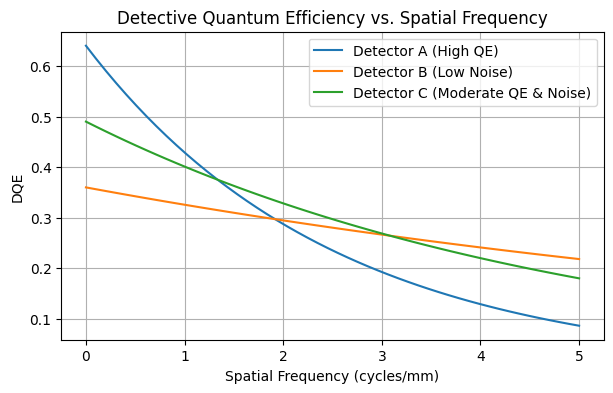

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def compute_dqe(snr_in, snr_out):
    return (snr_out ** 2) / (snr_in ** 2)

# Example data for two detectors
spatial_freq = np.linspace(0, 5, 50)  # cycles/mm
snr_in = 100 * np.exp(-0.2 * spatial_freq)
snr_out_A = 80 * np.exp(-0.4 * spatial_freq)  # High QE, moderate noise
snr_out_B = 60 * np.exp(-0.25 * spatial_freq)  # Lower QE, low noise

#Third detector
snr_out_C = 70 * np.exp(-0.3 * spatial_freq)

dqe_A = compute_dqe(snr_in, snr_out_A)
dqe_B = compute_dqe(snr_in, snr_out_B)
dqe_C = compute_dqe(snr_in, snr_out_C) # Added calculation for dqe_C

plt.figure(figsize=(7,4))
plt.plot(spatial_freq, dqe_A, label='Detector A (High QE)')
plt.plot(spatial_freq, dqe_B, label='Detector B (Low Noise)')
plt.plot(spatial_freq, dqe_C, label='Detector C (Moderate QE & Noise)')
plt.xlabel('Spatial Frequency (cycles/mm)')
plt.ylabel('DQE')
plt.title('Detective Quantum Efficiency vs. Spatial Frequency')
plt.legend()
plt.grid(True)
plt.show()

# TODO: Briefly discuss how your changes affect the DQE curves.

**Coding Exercise 6: Discussion of DQE curves**

Detector A: With higher initial SNR_out (80 at zero frequency) but a faster decay rate, Detector A starts with the highest DQE at low spatial frequencies due to its high quantum efficiency. However, because its SNR decreases more rapidly with frequency, its DQE drops more quickly at higher spatial frequencies, meaning it loses fine detail performance as frequency increases.

Detector B: With lower initial SNR_out (60 at zero frequency) but a slower decay rate, Detector B begins with a lower DQE at low spatial frequencies due to its lower quantum efficiency. However, because its SNR decreases more gradually, it maintains relatively better performance at higher spatial frequencies, preserving fine structural detail better than Detector A.

Detector C: With moderate initial SNR_out (70 at zero frequency) and a moderate decay rate, Detector C falls between A and B across the frequency range. It performs better than Detector B at low spatial frequencies due to higher initial signal, and retains high-frequency detail better than Detector A because its decay is less steep. This results in a more balanced DQE curve across spatial frequencies.

### **Coding Exercise 7**

1. Display the original image.
2. Apply contrast enhancement.
3. Apply brightness adjustment.
4. Display the adjusted images side-by-side.
5. Discuss how these changes affect image quality and visibility of features.

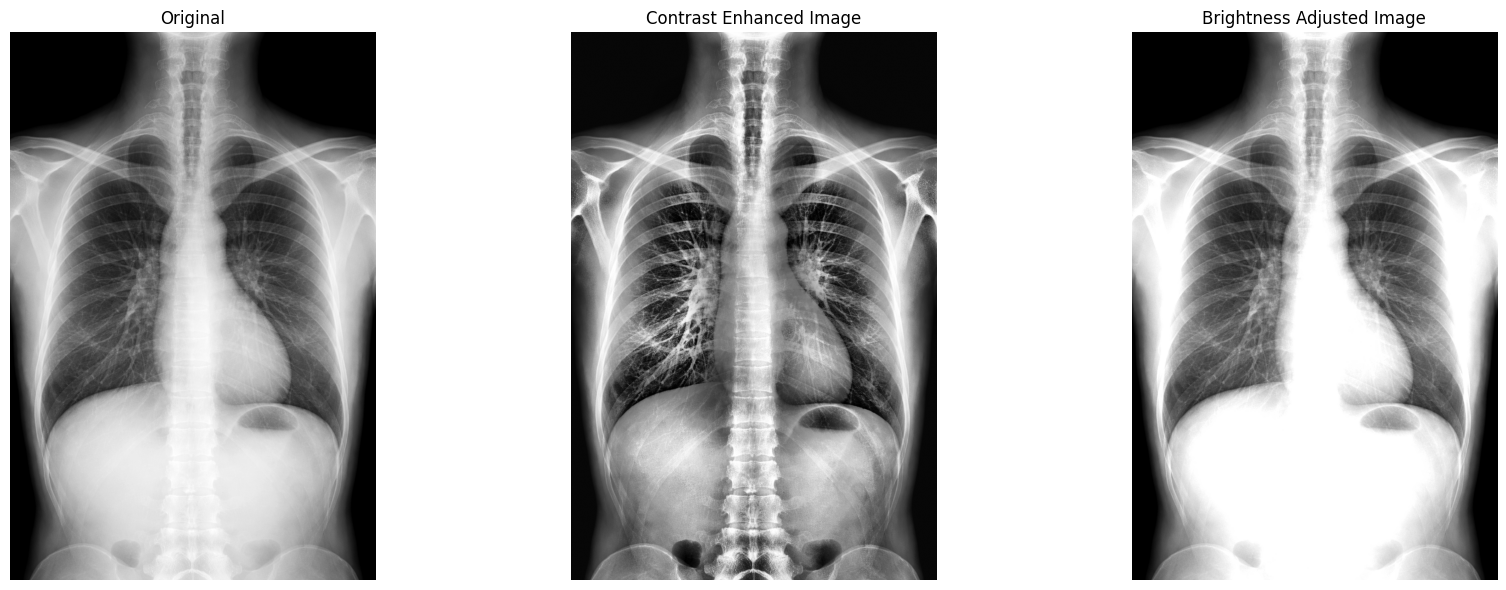


Discussion of Image Adjustments:
Discussion is provided in a separate markdown cell right below.


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure, io

#IMAGE: 'Xray_Chest.png'
img = io.imread('Xray_Chest.png', as_gray=True)

#Normalize to 0–1 range
img = img.astype(float)
img = img / np.max(img)

#Apply contrast enhancement (CLAHE)
contrast_enhanced_img = exposure.equalize_adapthist(img, clip_limit=0.03)

#Apply brightness adjustment
brightness_adjusted_img = np.clip(img + 0.2, 0, 1)

#Display the images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(contrast_enhanced_img, cmap='gray')
ax[1].set_title('Contrast Enhanced Image')
ax[1].axis('off')

ax[2].imshow(brightness_adjusted_img, cmap='gray')
ax[2].set_title('Brightness Adjusted Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

print("\nDiscussion of Image Adjustments:")
print("Discussion is provided in a separate markdown cell right below.")

**Coding Exericse 7: Discussion of Image Adjustments**

Original Image: The raw chest X-ray serves as the baseline for comparison. It shows the natural distribution of brightness and contrast without any post-processing adjustments.

Contrast-Enhanced Image: This adjustment increases the difference between light and dark regions, making anatomical structures such as ribs and lung markings more distinct. Subtle features become easier to identify, especially in areas that originally appeared flat or low contrast. However, excessive contrast enhancement can exaggerate noise or produce slightly artificial-looking textures.

Brightness-Adjusted Image: Adjusting brightness increases the overall lightness of the image, making darker regions easier to visualize. This can help reveal structures that may appear underexposed in the original image. However, increasing brightness too much can reduce dynamic range and cause bright areas to appear washed out.

Careful adjustment of both brightness and contrast is important to improve visibility while preserving diagnostic detail.

---

## Part 5: Computed Tomography (CT) Principles & Image Reconstruction



### Key Concepts

- **Hounsfield Units (HU):** Quantifies tissue attenuation relative to water.

$$HU = 1000 \cdot \frac{\mu_{tissue} - \mu_{water}}{\mu_{water}}$$
- **CT Projections:** Each projection is a line integral of attenuation coefficients along a path through the object:

$$P(\theta, t) = \int \mu(x, y) ds$$
- **Sinogram:** A 2D plot of projection data as a function of angle and position; each point in the object traces a sinusoidal path in the sinogram.
- **Image Reconstruction:** Filtered backprojection and iterative methods reconstruct the 2D image from projections.


### 5.1 Hounsfield Units and Tissue Contrast


### **Questions 7**

- a)  Define the Hounsfield unit and explain how it is calculated from measured attenuation coefficients.

The Hounsfield unit (HU) is a quantitative scale used in CT imaging to describe how strongly a material attenuates X-rays relative to water. It is based on the linear attenuation coefficient (μ) of a tissue compared to that of water. Water is defined as 0 HU, and other tissues are scaled relative to it using the formula:

HU=1000⋅μwater​μtissue​−μwater​​

- b) Calculate the HU for a tissue with:

$$
\mu_{\text{tissue}} = 0.22\ \text{cm}^{-1}, \quad
\mu_{\text{water}} = 0.20\ \text{cm}^{-1}, \quad
\mu_{\text{air}} = 0.0002\ \text{cm}^{-1}
$$

Show your calculation step by step.

$$HU = 1000 \cdot \frac{\mu_{tissue} - \mu_{water}}{\mu_{water}}$$

$$HU = 1000 \cdot \frac{\mu_{0.22} - \mu_{0.20}}{\mu_{0.20}}$$

$$HU = 1000 \cdot 0.1$$

$$HU = 100$$


- c) Discuss the clinical significance of HU values in CT imaging.

HU provide a quantitative measure of tissue density in CT imaging. Since different tissues have characteristic HU ranges (for example, air near −1000 HU, water at 0 HU, and dense bone at high positive values), clinicians can use these values to distinguish normal anatomy from pathology. HU measurements assist in identifying calcifications, hemorrhage, fat-containing lesions, and differentiating cystic from solid masses. The standardized scale also allows consistent interpretation across different CT scanners and supports diagnosis, treatment planning, and monitoring of disease progression.


### **Coding Exercise 8**

1. Create a 2D numpy array representing a phantom with a circular region of higher attenuation.
2. Simulate the projection (sum of attenuation) at a given angle.
3. Plot the phantom and its projection profile.

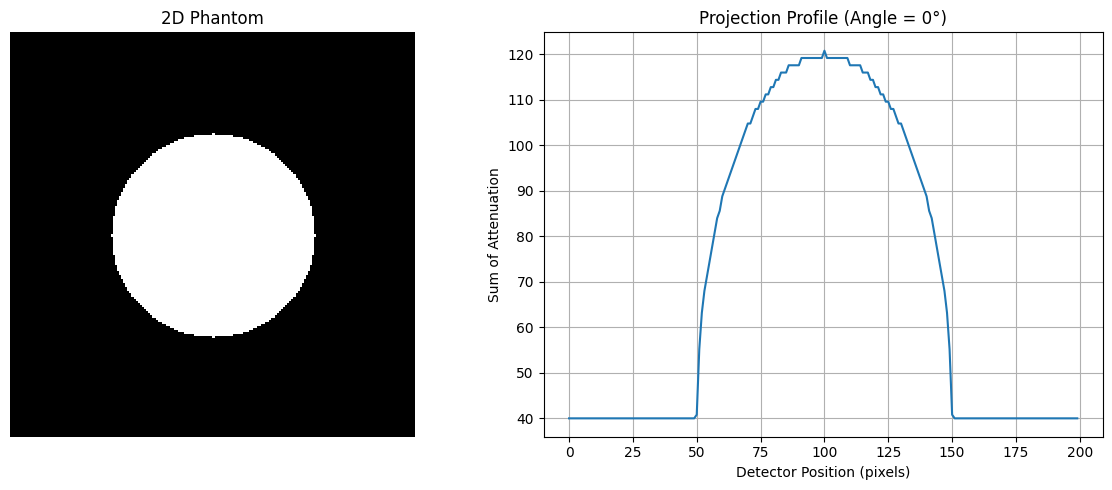

In [13]:
import numpy as np
import matplotlib.pyplot as plt

N = 200
radius = 50
mu_background = 0.2
mu_circle = 1.0
angle_deg = 0  # 0 degrees = sum along columns

#Create a 2D numpy array phantom with a circular region
phantom = np.full((N, N), mu_background, dtype=float)
y, x = np.ogrid[:N, :N]
cx, cy = N // 2, N // 2
mask = (x - cx)**2 + (y - cy)**2 <= radius**2
phantom[mask] = mu_circle

#Simulate the projection (sum of attenuation) at a given angle
if angle_deg == 0:
    projection = np.sum(phantom, axis=0)
elif angle_deg == 90:
    projection = np.sum(phantom, axis=1)
else:
    projection = np.sum(phantom, axis=0)

#Plot the phantom and its projection profile
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(phantom, cmap="gray", interpolation="nearest")
axes[0].set_title("2D Phantom")
axes[0].axis("off")

axes[1].plot(projection)
axes[1].set_title(f"Projection Profile (Angle = {angle_deg}°)")
axes[1].set_xlabel("Detector Position (pixels)")
axes[1].set_ylabel("Sum of Attenuation")
axes[1].grid(True)  # <-- Added grid here

plt.tight_layout()
plt.show()

---

## Part 6: CT Image Quality, Artifacts, and Dose Optimization



### Key Concepts

- **Streak Artifacts:** Appear as bright/dark lines, often caused by high-attenuation objects (metal), beam hardening (lower energy photons absorbed more), or photon starvation (very low signal).
- **Noise:** In CT, noise is primarily quantum (photon) noise and is inversely proportional to the square root of dose:

$$\sigma = \frac{K}{\sqrt{D}}$$
- **Dose Optimization:** The goal is to minimize patient dose while maintaining diagnostic image quality. Techniques include automatic exposure control and iterative reconstruction.


### 6.1 CT Streak Artifact Analysis

### **Questions 8**

- a) Carefully examine the artifact in the image. Describe the physical and mathematical causes of streak artifacts in CT (reference concepts such as beam hardening, photon starvation, and reconstruction errors).

The image shows bright streaks extending from a high-attenuation region near the skull. These streaks are caused by several physical and mathematical factors:

Beam hardening: As the X-ray beam passes through dense bone or metal, lower-energy photons are absorbed more than higher-energy photons. This changes the energy spectrum of the beam, violating the reconstruction assumption of a monoenergetic beam and producing nonlinear attenuation errors that appear as streaks.

Photon starvation: Very dense regions allow very few photons to reach the detector, increasing quantum noise in those projections. During reconstruction, this noise is amplified and appears as streaking across the image.

Reconstruction model errors: Filtered backprojection assumes accurate line integrals of attenuation. When projection data are inconsistent due to noise or beam hardening, the reconstruction spreads these errors along projection paths, forming streak artifacts.

- b) Propose and explain at least two algorithmic or acquisition-based strategies to reduce or mitigate streak artifacts in clinical CT.

Beam hardening correction: Apply software corrections that compensate for polychromatic beam effects, or use dual-energy CT to better model material-dependent attenuation.

Iterative reconstruction: Use reconstruction methods that model noise and system physics more accurately, reducing noise amplification and streak formation.

Dose and acquisition optimization: Increase mA or use automatic exposure control to reduce photon starvation, and adjust kVp to reduce beam hardening while maintaining acceptable patient dose.
Together, these strategies aim to improve image quality while balancing radiation dose.


### **Coding Exercise 9**

1. Write a function `ct_noise_vs_dose(D, K)`.
2. Plot image noise as a function of dose for $K=10$ and $D$ from 1 to 100 (arbitrary units).

a) Causes of the streak artifact
The image shows bright streaks extending from a high-attenuation region near the skull. These streaks are caused by several physical and mathematical factors:

- Beam hardening: As the X-ray beam passes through dense bone or metal, lower-energy photons are absorbed more than higher-energy photons. This changes the energy spectrum of the beam, violating the reconstruction assumption of a monoenergetic beam and producing nonlinear attenuation errors that appear as streaks.

- Photon starvation: Very dense regions allow very few photons to reach the detector, increasing quantum noise in those projections. During reconstruction, this noise is amplified and appears as streaking across the image.

- Reconstruction model errors: Filtered backprojection assumes accurate line integrals of attenuation. When projection data are inconsistent due to noise or beam hardening, the reconstruction spreads these errors along projection paths, forming streak artifacts.

b) Strategies to reduce streak artifacts

- Beam hardening correction: Apply software corrections that compensate for polychromatic beam effects, or use dual-energy CT to better model material-dependent attenuation.

- Iterative reconstruction: Use reconstruction methods that model noise and system physics more accurately, reducing noise amplification and streak formation.

- Dose and acquisition optimization: Increase mA or use automatic exposure control to reduce photon starvation, and adjust kVp to reduce beam hardening while maintaining acceptable patient dose.
Together, these strategies aim to improve image quality while balancing radiation dose.

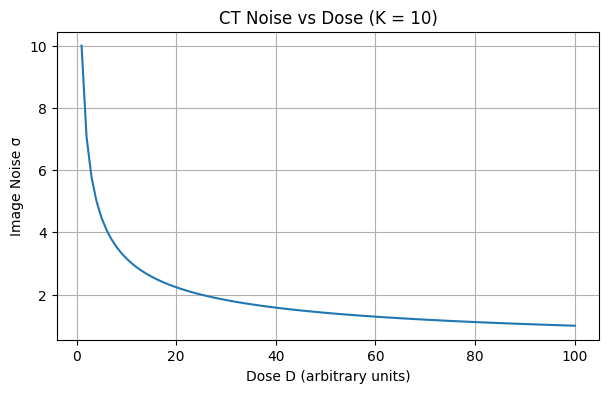


Analysis and Discussion:
Noise decreases as dose increases because σ is inversely proportional to the square root of dose.
This creates diminishing returns: doubling dose reduces noise by a factor of √2, not by half.
Clinically, this supports dose optimization: increasing dose improves image quality, but large dose increases
are needed for small noise reductions, so the goal is the lowest dose that still maintains diagnostic quality.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# USE IMAGE 'Brain_CT.png'

#Write a function ct_noise_vs_dose(D, K)
def ct_noise_vs_dose(D, K):
    return K / np.sqrt(D)

#Plot image noise as a function of dose
K = 10
D = np.linspace(1, 100, 100)
noise = ct_noise_vs_dose(D, K)

plt.figure(figsize=(7, 4))
plt.plot(D, noise, markersize=3)
plt.xlabel("Dose D (arbitrary units)")
plt.ylabel("Image Noise σ")
plt.title("CT Noise vs Dose (K = 10)")
plt.grid(True)
plt.show()

#Analyze and discuss the results
print("\nAnalysis and Discussion:")
print("Noise decreases as dose increases because σ is inversely proportional to the square root of dose.")
print("This creates diminishing returns: doubling dose reduces noise by a factor of √2, not by half.")
print("Clinically, this supports dose optimization: increasing dose improves image quality, but large dose increases")
print("are needed for small noise reductions, so the goal is the lowest dose that still maintains diagnostic quality.")

---

## Part 7: Quantitative Analysis of CT Image Quality

### Key Concepts

- **SNR (Signal-to-Noise Ratio):**

$$\mathrm{SNR} = \frac{\mu_{signal}}{\sigma_{noise}}$$
- **RMSE (Root Mean Square Error):** Measures the average difference between two images:

$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^N (I_i - I_{ref,i})^2}$$
- **Filtering:** Denoising filters (Gaussian, median, bilateral) can reduce noise but may blur edges or reduce detail.


### 7.1 SNR and RMSE Analysis


### **Coding Exercise 10**

1. Apply a denoising or edge-preserving filter of your choice (e.g., Gaussian, median, or bilateral filter).
2. Compute and compare the following metrics before and after filtering:
   - Signal-to-Noise Ratio (SNR)
   - Root Mean Square Error (RMSE)
   (You may use the original image as reference for RMSE, or compare to a region of interest.)
3. Discuss what these metrics reveal about image quality and the impact of filtering.

SNR before filtering: 0.8264
SNR after filtering:  0.8324
RMSE (original vs filtered): 0.0158


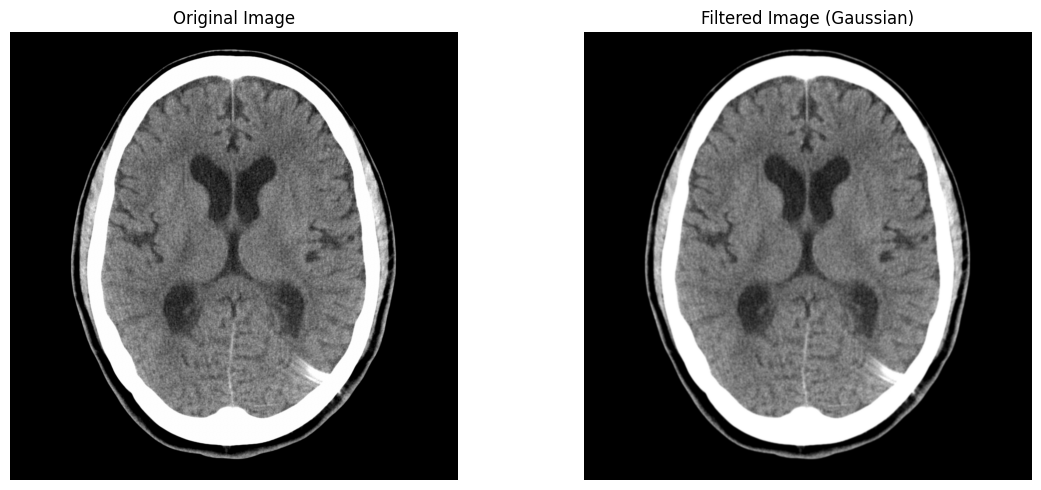

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import gaussian
from skimage.metrics import mean_squared_error

# USE IMAGE 'Brain_CT.png'
img = io.imread('Brain_CT.png', as_gray=True).astype(float)
img = img / np.max(img)

#Apply a filter to img (e.g., Gaussian, median, etc.)
filtered_img = gaussian(img, sigma=1.0, preserve_range=True)

#Compute SNR and RMSE before and after filtering
def compute_snr(image):
    return np.mean(image) / np.std(image)

snr_before = compute_snr(img)
snr_after = compute_snr(filtered_img)

rmse = np.sqrt(mean_squared_error(img, filtered_img))

print(f"SNR before filtering: {snr_before:.4f}")
print(f"SNR after filtering:  {snr_after:.4f}")
print(f"RMSE (original vs filtered): {rmse:.4f}")

#Visualize the original and filtered images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(filtered_img, cmap='gray')
axes[1].set_title('Filtered Image (Gaussian)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Coding exercise 10: Discussion (image quality and the impact of filtering)**

Filtering reduces noise (lower standard deviation), so SNR usually increases after filtering. RMSE measures how much the filtered image differs from the original; RMSE increases as filtering strength increases because smoothing changes pixel values and can blur edges. Together, these metrics show the trade-off: improved apparent noise performance (higher SNR) versus loss of fine detail (higher RMSE).

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable2.ipynb` and `.pdf`

**Due:** Monday, March 2, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Analysis Due |
|---------|------------------------|
| **Part 1: X-ray Production & Spectrum** | Q1 (a,b,c), Coding Exercise 1 |
| **Part 2: CT Simulation, Error Analysis & Design** | Coding Exercise 2, Q2 (a,b,c), Coding Exercise 3, Q3 (a,b,c,d)  |
| **Part 3: Projection Radiography & Image Quality** | Q4 (a,b,c), Coding Exercise 4, Q5 (a,b), Coding Exercise 5 |
| **Part 4: X-ray Detectors & Quantum Efficiency** | Q6 (a,b,c), Coding Exercise 6, Coding Exercise 7|
| **Part 5: CT Principles & Image Reconstruction** | Q7 (a,b,c), Coding Exercise 8|
| **Part 6: CT Image Quality, Artifacts & Dose Optimization** | Q8 (a,b), Coding Exercise 9 |
| **Part 7: Quantitative Analysis of CT Image Quality** | Coding Exercise 10 |
